In [6]:
import requests
import numpy as np
from curses.ascii import isalpha, isdigit
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

In [7]:
def get_stoich_reduced_list_from_prototype(prototype_label):
    """
    Get numerical list of stoichiometry from prototype label, i.e. 'AB3_....' -> [1,3]

    Args:
        prototype_label:
            AFLOW prototype label

    Returns:
        List of reduced stoichiometric numbers
    """                        
    stoich_reduced_formula = prototype_label.split("_")[0]
    # print("stoich_reduced_formula",stoich_reduced_formula)
    stoich_reduced_list=[]
    stoich_reduced_curr = None
    for char in stoich_reduced_formula:
        # print(f"char = {char} | stoich_reduced_curr {stoich_reduced_curr} | stoich_reduced_list {stoich_reduced_list}")
        if isalpha(char):
            if stoich_reduced_curr is not None:
                if stoich_reduced_curr == 0:
                    stoich_reduced_curr = 1
                stoich_reduced_list.append(stoich_reduced_curr)
            stoich_reduced_curr = 0
        else:
            assert isdigit(char)                            
            stoich_reduced_curr*=10 # will throw an error if we haven't encountered an alphabetical letter, good
            stoich_reduced_curr+=int(char)
    # write final number                    
    if stoich_reduced_curr == 0:
        stoich_reduced_curr = 1
    stoich_reduced_list.append(stoich_reduced_curr)    
    return stoich_reduced_list


In [8]:
get_stoich_reduced_list_from_prototype("A23B3_cF16")

[23, 3]

In [9]:
def get_formation_energies(species_list,model=None):
    """
    Query OpenKIM repository for test results or reference data for constructing a thermodynamic hull.
    Args:
        species_list:
            List of all species to query for. Every result or data containing any combination of one or more of these will be returned
        model:
            OpenKIM model to query for. If this is None, reference data are queried for instead

    Returns:
        * (N, len(species_list)) ndarray representing N points to build the hull out of. The last column is the energy, the others are the molar fractions of each element in species_list except the first
        * N-length list of prototype labels
        * len(species_list)-length list of indices into the previous two outputs indicating the elemental reference for each 
    """
    assert len(species_list)>1
    assert len(set(species_list))==len(species_list)
    if model==None:
        model_query=''
        meta_type='rd'
    else:
        model_query='"meta.subject.extended-id":"%s",'%model
        meta_type='tr'
    
    post_data = {'query': '{"meta.type":"%s",%s"property-id":"tag:staff@noreply.openkim.org,2023-02-21:property/binding-energy-crystal","stoichiometric-species.source-value":{"$not":{"$elemMatch":{"$nin":%s}}}}'%(meta_type,model_query,str(species_list).replace("'",'"')), 'fields': '{"prototype-label.source-value":1,"stoichiometric-species.source-value":1,"binding-potential-energy-per-formula.source-value":1}', 'database': 'data'}
    # print("post_data",post_data)
    # print("-----------------")
    
    result = requests.post("https://query.openkim.org/api",data= post_data).json()
    # for r in result:
        # print("RESULT",r)
        # print("-----------------")
        
    # initialize dict for elemental references
    elemental_references = []
    reference_indices = []
    for species in species_list:
        elemental_references.append(0.)
        reference_indices.append(-1)
    
    # find the mono-species with minimum energy. this will be used as the
    # energy E_i of the species i when calculating E_total - SUM(x_i * E_i)
    # elemental_references  : array of len(species_list) and has minimum-energy for each species
    # reference_indices     : which entry in the query-results has minimum-energy for the given species 
    for i,entry in enumerate(result):
        species=entry["stoichiometric-species"]["source-value"]
        if len(species) != 1: continue
        # only mono-species structures henceforth
        energy = entry["binding-potential-energy-per-formula"]["source-value"]
        species = species[0]
        species_index=species_list.index(species)
        if energy < elemental_references[species_index]:
            elemental_references[species_index] = energy
            reference_indices[species_index] = i
    
    #now build the hull list of dicts
    prototype_labels=[]
    hull_pts = np.ndarray((len(result),len(species_list)))
    # each row in hull_pts matrix is 
    # [x_B, x_C, x_D, ..., FormationEnergy] 
    # where x_B is the proportion of element B in the structure with prototype-label A2-B1-C3-D1. 
    # we can drop x_A because x_A = 1 - (x_B + x_C + x_D + ...)

    for i,entry in enumerate(result):
        prototype_label = entry["prototype-label"]["source-value"]
        prototype_labels.append(prototype_label)
        curr_species_list = entry["stoichiometric-species"]["source-value"]
        stoich_reduced_list = get_stoich_reduced_list_from_prototype(prototype_label)
        stoich_reduced_list_full = np.zeros(len(species_list))
        for (element,stoich_num) in zip(curr_species_list,stoich_reduced_list):
            species_index = species_list.index(element)
            if i < 5: 
                print(f"PROTOTYPE_LABEL {prototype_label} | element {element} | stoich_num {stoich_num} | species_index {species_index}")
            stoich_reduced_list_full[species_index]=stoich_num
        if i < 5: 
            print(f"PROTOTYPE_LABEL {prototype_label} | CURR_SPEC_LIST {curr_species_list} | STOICH_LIST {stoich_reduced_list} | STOICH_LIST_FULL {stoich_reduced_list_full}\n------------")
        #set the coordinates to the stoichiometry, skipping first element
        num_atoms_in_formula = sum(stoich_reduced_list_full)

        # row i, all columns except last one = x_B, x_C, x_D, ... for ith structure 
        hull_pts[i,:-1]=[elem_num/num_atoms_in_formula for elem_num in stoich_reduced_list_full][1:]
        
        # row i, last column = FormationEnergy for ith structure
        hull_pts[i,-1]=(entry["binding-potential-energy-per-formula"]["source-value"] - np.dot(elemental_references,stoich_reduced_list_full))/num_atoms_in_formula

    for h in range(len(hull_pts)):
        if h == 5: break
        print("hull_pts",hull_pts[h])
    print("---------")

    return hull_pts,prototype_labels,reference_indices

In [10]:
post_data = {'query': '{"meta.type":"rd","property-id":"tag:staff@noreply.openkim.org,2023-02-21:property/binding-energy-crystal","stoichiometric-species.source-value":{"$not":{"$elemMatch":{"$nin":["Ni", "Al"]}}}}', 'fields': '{"prototype-label.source-value":1,"stoichiometric-species.source-value":1,"binding-potential-energy-per-formula.source-value":1}', 'database': 'data'}
result = requests.post("https://query.openkim.org/api",data= post_data).json()
for i in range(5):
    print(i,result[i])

0 {'prototype-label': {'source-value': 'A3B2_hP5_164_ad_d'}, 'stoichiometric-species': {'source-value': ['Al', 'Ni']}, 'binding-potential-energy-per-formula': {'source-value': -18.172649999999997}}
1 {'prototype-label': {'source-value': 'AB3_cP4_221_a_c'}, 'stoichiometric-species': {'source-value': ['Al', 'Ni']}, 'binding-potential-energy-per-formula': {'source-value': -11.44952}}
2 {'prototype-label': {'source-value': 'AB_cP2_221_a_b'}, 'stoichiometric-species': {'source-value': ['Al', 'Ni']}, 'binding-potential-energy-per-formula': {'source-value': -7.06876}}
3 {'prototype-label': {'source-value': 'A3B_oP16_62_cd_c'}, 'stoichiometric-species': {'source-value': ['Al', 'Ni']}, 'binding-potential-energy-per-formula': {'source-value': -14.79132}}
4 {'prototype-label': {'source-value': 'A_cF4_225_a'}, 'stoichiometric-species': {'source-value': ['Ni']}, 'binding-potential-energy-per-formula': {'source-value': -2.04439}}


In [11]:
hull_pts,prototype_labels,reference_indices = get_formation_energies(["Ni","Al"])
print(hull_pts[:5])
print(prototype_labels[:5])
print(reference_indices[:5])

PROTOTYPE_LABEL A3B2_hP5_164_ad_d | element Al | stoich_num 3 | species_index 1
PROTOTYPE_LABEL A3B2_hP5_164_ad_d | element Ni | stoich_num 2 | species_index 0
PROTOTYPE_LABEL A3B2_hP5_164_ad_d | CURR_SPEC_LIST ['Al', 'Ni'] | STOICH_LIST [3, 2] | STOICH_LIST_FULL [2. 3.]
------------
PROTOTYPE_LABEL AB3_cP4_221_a_c | element Al | stoich_num 1 | species_index 1
PROTOTYPE_LABEL AB3_cP4_221_a_c | element Ni | stoich_num 3 | species_index 0
PROTOTYPE_LABEL AB3_cP4_221_a_c | CURR_SPEC_LIST ['Al', 'Ni'] | STOICH_LIST [1, 3] | STOICH_LIST_FULL [3. 1.]
------------
PROTOTYPE_LABEL AB_cP2_221_a_b | element Al | stoich_num 1 | species_index 1
PROTOTYPE_LABEL AB_cP2_221_a_b | element Ni | stoich_num 1 | species_index 0
PROTOTYPE_LABEL AB_cP2_221_a_b | CURR_SPEC_LIST ['Al', 'Ni'] | STOICH_LIST [1, 1] | STOICH_LIST_FULL [1. 1.]
------------
PROTOTYPE_LABEL A3B_oP16_62_cd_c | element Al | stoich_num 3 | species_index 1
PROTOTYPE_LABEL A3B_oP16_62_cd_c | element Ni | stoich_num 1 | species_index 0
PR

In [12]:
def get_2d_lower_hull(species_list,model=None):
    """
    Build 2d lower hull from OpenKim query
    Args:
        species_list:
            List of all species to query for. Every result or data containing any combination of one or more of these will be returned
        model:
            OpenKIM model to query for. If this is None, reference data are queried for instead

    Returns:
        * (N, len(species_list)) ndarray representing N points the hull was built from. The last column is the energy, the others are the molar fractions of each element in species_list except the first
        * N-length list of prototype labels
        * list of indices corresponding to points constituting the lower hull
    """
    hull_pts,prototype_labels,reference_indices=get_formation_energies(species_list,model)

    hull = ConvexHull(hull_pts)

    #In 2D, ConvexHull.vertices are guaranteed to be counter-clockwise. So we just need to go from reference_indices[0] to [1], possibly wrapping around

    print(reference_indices[:5])
    print(hull.vertices)
    
    lower_hull_vertices = [reference_indices[0]]
    i = list(hull.vertices).index(reference_indices[0])
    while hull.vertices[i] != reference_indices[1]:
        i = (i+1)%len(hull.vertices)
        lower_hull_vertices.append((int)(hull.vertices[i]))

    return hull_pts, prototype_labels, lower_hull_vertices

In [17]:
hull_pts, prototype_labels, lower_hull_vertices = get_2d_lower_hull(["Ni","Al"])
print("LHV",lower_hull_vertices)

PROTOTYPE_LABEL A3B2_hP5_164_ad_d | element Al | stoich_num 3 | species_index 1
PROTOTYPE_LABEL A3B2_hP5_164_ad_d | element Ni | stoich_num 2 | species_index 0
PROTOTYPE_LABEL A3B2_hP5_164_ad_d | CURR_SPEC_LIST ['Al', 'Ni'] | STOICH_LIST [3, 2] | STOICH_LIST_FULL [2. 3.]
------------
PROTOTYPE_LABEL AB3_cP4_221_a_c | element Al | stoich_num 1 | species_index 1
PROTOTYPE_LABEL AB3_cP4_221_a_c | element Ni | stoich_num 3 | species_index 0
PROTOTYPE_LABEL AB3_cP4_221_a_c | CURR_SPEC_LIST ['Al', 'Ni'] | STOICH_LIST [1, 3] | STOICH_LIST_FULL [3. 1.]
------------
PROTOTYPE_LABEL AB_cP2_221_a_b | element Al | stoich_num 1 | species_index 1
PROTOTYPE_LABEL AB_cP2_221_a_b | element Ni | stoich_num 1 | species_index 0
PROTOTYPE_LABEL AB_cP2_221_a_b | CURR_SPEC_LIST ['Al', 'Ni'] | STOICH_LIST [1, 1] | STOICH_LIST_FULL [1. 1.]
------------
PROTOTYPE_LABEL A3B_oP16_62_cd_c | element Al | stoich_num 3 | species_index 1
PROTOTYPE_LABEL A3B_oP16_62_cd_c | element Ni | stoich_num 1 | species_index 0
PR

In [30]:
def plot_model_hull_vs_rd(species,model):
    """
    Plot binary hull of model vs. binary hull of reference data
    Args:
        species:
            List species
        model:
            OpenKIM model
    """        
    rd_form_engy_array,rd_prototype_labels,rd_hull_vert_inds=get_2d_lower_hull(species)
    mo_form_engy_array,mo_prototype_labels,mo_hull_vert_inds=get_2d_lower_hull(species,model)

    # get arrays of vertex coords and protos
    rd_hull_verts = rd_form_engy_array[rd_hull_vert_inds]
    rd_hull_protos = [rd_prototype_labels[i] for i in rd_hull_vert_inds]
    mo_hull_verts = mo_form_engy_array[mo_hull_vert_inds]

    mo_hull_vert_inds_correct=[]
    mo_hull_vert_inds_incorrect=[]
    for i in mo_hull_vert_inds:
        if mo_prototype_labels[i] in rd_hull_protos:
            mo_hull_vert_inds_correct.append(i)
        else:
            mo_hull_vert_inds_incorrect.append(i)

    mo_hull_verts_correct = mo_form_engy_array[mo_hull_vert_inds_correct]
    mo_hull_verts_incorrect = mo_form_engy_array[mo_hull_vert_inds_incorrect]

    plt.rcParams['font.size']=16
    fig, ax = plt.subplots()
    ax.set_xlim(0.,1.)
    ax.set_ylim(ymin=1.2*min(min(rd_form_engy_array[:,1]),min(mo_form_engy_array[:,1])),ymax=0.)
    ax.set_xlabel("Mole fraction of %s"%species[1])
    ax.set_ylabel("$H_f$ (eV/atom)")
    if model:
        ax.set_title(model+"\n")


    ax.plot(mo_hull_verts[:,0],mo_hull_verts[:,1],"k-")
    ip_pts,=ax.plot(mo_form_engy_array[:,0],mo_form_engy_array[:,1],"kx",label="IP calculations")
    ax.plot(rd_hull_verts[:,0],rd_hull_verts[:,1],"m--")
    rd_pts,=ax.plot(rd_form_engy_array[:,0],rd_form_engy_array[:,1],"mx",label="DFT calculations")
    ip_hull_correct,=ax.plot(mo_hull_verts_correct[:,0],mo_hull_verts_correct[:,1],"bo",label="Prototype agrees\nwith DFT")
    ip_hull_incorrect,=ax.plot(mo_hull_verts_incorrect[:,0],mo_hull_verts_incorrect[:,1],"ro",label="Prototype disagrees\nwith DFT") 

    fig.legend(handles=[ip_pts,rd_pts,ip_hull_correct,ip_hull_incorrect],loc="lower right")

PROTOTYPE_LABEL A_hP2_194_c | element Ti | stoich_num 1 | species_index 0
PROTOTYPE_LABEL A_hP2_194_c | CURR_SPEC_LIST ['Ti'] | STOICH_LIST [1] | STOICH_LIST_FULL [1. 0.]
------------
PROTOTYPE_LABEL AB_tP2_123_a_d | element Al | stoich_num 1 | species_index 1
PROTOTYPE_LABEL AB_tP2_123_a_d | element Ti | stoich_num 1 | species_index 0
PROTOTYPE_LABEL AB_tP2_123_a_d | CURR_SPEC_LIST ['Al', 'Ti'] | STOICH_LIST [1, 1] | STOICH_LIST_FULL [1. 1.]
------------
PROTOTYPE_LABEL A3B_tI8_139_ad_b | element Al | stoich_num 3 | species_index 1
PROTOTYPE_LABEL A3B_tI8_139_ad_b | element Ti | stoich_num 1 | species_index 0
PROTOTYPE_LABEL A3B_tI8_139_ad_b | CURR_SPEC_LIST ['Al', 'Ti'] | STOICH_LIST [3, 1] | STOICH_LIST_FULL [1. 3.]
------------
PROTOTYPE_LABEL A_hP2_194_c | element Ti | stoich_num 1 | species_index 0
PROTOTYPE_LABEL A_hP2_194_c | CURR_SPEC_LIST ['Ti'] | STOICH_LIST [1] | STOICH_LIST_FULL [1. 0.]
------------
PROTOTYPE_LABEL AB3_hP8_194_c_h | element Al | stoich_num 1 | species_inde

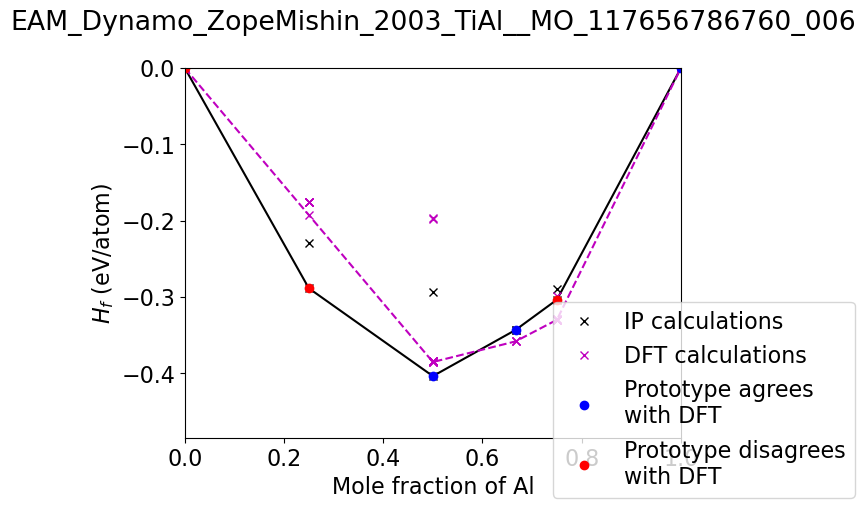

In [32]:
import matplotlib.pyplot as plt

species=["Ti","Al"]

model="EAM_Dynamo_ZopeMishin_2003_TiAl__MO_117656786760_006"
# model="EAM_Dynamo_FarkasJones_1996_NbTiAl__MO_042691367780_001"
# model="MEAM_LAMMPS_AlmyrasSangiovanniSarakinos_2019_NAlTi__MO_958395190627_001"
#model="MEAM_LAMMPS_KimKimJung_2016_AlTi__MO_618133763375_001"
#model="MEAM_LAMMPS_KimKimJung_2017_NiAlTi__MO_478967255435_001"
#model="MEAM_LAMMPS_SunRamachandranWick_2018_TiAl__MO_022920256108_001"
#model="Tersoff_LAMMPS_PlummerRathodSrivastava_2021_TiAlC__MO_992900971352_000"

# model = None

assert len(species)==2

plot_model_hull_vs_rd(species,model)

# 3D plot for Ternary Phase Diagram

In [23]:
def get_ternary_lower_hull(hull_pts):
    hull = ConvexHull(hull_pts)

    lower_hull_faces = []
    lower_hull_vertices = set()

    for simplex, eq in zip(hull.simplices, hull.equations):
        normal = eq[:-1]   # (a, b, c)
        
        if normal[-1] < 0:   # c > 0 → lower hull
            lower_hull_faces.append(simplex)
            lower_hull_vertices.update(simplex)

    return list(lower_hull_vertices), lower_hull_faces

In [ ]:
hull_pts,prototype_labels,reference_indices = get_formation_energies(["Ni","Ti","Al"])

PROTOTYPE_LABEL A3B2_hP5_164_ad_d | element Al | stoich_num 3 | species_index 2
PROTOTYPE_LABEL A3B2_hP5_164_ad_d | element Ni | stoich_num 2 | species_index 0
PROTOTYPE_LABEL A3B2_hP5_164_ad_d | CURR_SPEC_LIST ['Al', 'Ni'] | STOICH_LIST [3, 2] | STOICH_LIST_FULL [2. 0. 3.]
------------
PROTOTYPE_LABEL A_hP2_194_c | element Ti | stoich_num 1 | species_index 1
PROTOTYPE_LABEL A_hP2_194_c | CURR_SPEC_LIST ['Ti'] | STOICH_LIST [1] | STOICH_LIST_FULL [0. 1. 0.]
------------
PROTOTYPE_LABEL AB_cP2_221_a_b | element Ni | stoich_num 1 | species_index 0
PROTOTYPE_LABEL AB_cP2_221_a_b | element Ti | stoich_num 1 | species_index 1
PROTOTYPE_LABEL AB_cP2_221_a_b | CURR_SPEC_LIST ['Ni', 'Ti'] | STOICH_LIST [1, 1] | STOICH_LIST_FULL [1. 1. 0.]
------------
PROTOTYPE_LABEL AB_tP2_123_a_d | element Al | stoich_num 1 | species_index 2
PROTOTYPE_LABEL AB_tP2_123_a_d | element Ti | stoich_num 1 | species_index 1
PROTOTYPE_LABEL AB_tP2_123_a_d | CURR_SPEC_LIST ['Al', 'Ti'] | STOICH_LIST [1, 1] | STOICH_L

In [24]:
hull_pts[:10]

array([[ 0.       ,  0.6      , -0.50642  ],
       [ 1.       ,  0.       ,  0.09001  ],
       [ 0.5      ,  0.       , -0.1502   ],
       [ 0.5      ,  0.5      , -0.384075 ],
       [ 0.5      ,  0.       , -0.16506  ],
       [ 0.       ,  0.25     , -0.2737075],
       [ 0.5      ,  0.       , -0.14779  ],
       [ 0.       ,  0.5      , -0.560395 ],
       [ 0.       ,  0.75     , -0.3385325],
       [ 0.25     ,  0.75     , -0.3292975]])

In [25]:
get_ternary_lower_hull(hull_pts)

([np.int32(129),
  np.int32(65),
  np.int32(161),
  np.int32(164),
  np.int32(197),
  np.int32(198),
  np.int32(72),
  np.int32(8),
  np.int32(75),
  np.int32(51),
  np.int32(21),
  np.int32(150),
  np.int32(181),
  np.int32(90)],
 [array([197, 150,  90], dtype=int32),
  array([197, 150, 129], dtype=int32),
  array([ 51, 197,  90], dtype=int32),
  array([ 72, 197, 129], dtype=int32),
  array([ 72,  51, 164], dtype=int32),
  array([ 72,  51, 197], dtype=int32),
  array([ 65,   8, 161], dtype=int32),
  array([198,  21,  90], dtype=int32),
  array([198,  51,  90], dtype=int32),
  array([ 75, 198,  51], dtype=int32),
  array([181,  21, 161], dtype=int32),
  array([181, 198,  21], dtype=int32),
  array([181,  75, 198], dtype=int32),
  array([181,   8, 161], dtype=int32)])

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def plot_ternary_lower_hull_3d(
    hull_pts,
    lower_hull_faces,
    stable_vertices=None,
    species_labels=("A", "B", "C"),
    point_size=40,
    alpha_faces=0.35,
    show_all_points=True,
    show_stable_points=True,
):
    """
    Plot a ternary lower hull in 3D.

    Parameters
    ----------
    hull_pts : (N, 3) ndarray
        Columns are:
            hull_pts[:, 0] = concentration of A
            hull_pts[:, 1] = concentration of B
            hull_pts[:, 2] = formation energy
        Concentration of C is implied:
            c_C = 1 - c_A - c_B

    lower_hull_faces : list of array-like of length 3
        Triangle vertex indices returned by get_ternary_lower_hull().

    stable_vertices : list[int] or None
        Stable vertex indices returned by get_ternary_lower_hull().
        If None, they will be inferred from lower_hull_faces.

    species_labels : tuple[str, str, str]
        Labels for (A, B, C). Pure C is at x=0, y=0.

    point_size : float
        Marker size for scatter points.

    alpha_faces : float
        Transparency for hull triangles.

    show_all_points : bool
        Whether to scatter all structures.

    show_stable_points : bool
        Whether to highlight stable structures.
    """
    hull_pts = np.asarray(hull_pts, dtype=float)

    if hull_pts.ndim != 2 or hull_pts.shape[1] != 3:
        raise ValueError("hull_pts must have shape (N, 3) with columns [c_A, c_B, H_f].")

    if stable_vertices is None:
        stable_vertices = sorted({idx for face in lower_hull_faces for idx in face})
    else:
        stable_vertices = sorted(set(stable_vertices))

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    x = hull_pts[:, 0]
    y = hull_pts[:, 1]
    z = hull_pts[:, 2]

    # Plot all points
    if show_all_points:
        ax.scatter(x, y, z, s=point_size, label="All structures")

    # Highlight stable points
    if show_stable_points and len(stable_vertices) > 0:
        stable_pts = hull_pts[stable_vertices]
        ax.scatter(
            stable_pts[:, 0],
            stable_pts[:, 1],
            stable_pts[:, 2],
            s=1.5 * point_size,
            marker="o",
            edgecolors="k",
            linewidths=0.8,
            label="Stable structures",
        )

    # Plot lower hull triangular faces
    triangles = [hull_pts[np.asarray(face)] for face in lower_hull_faces]
    poly = Poly3DCollection(triangles, alpha=alpha_faces, edgecolor="k")
    ax.add_collection3d(poly)

    # Draw triangle edges explicitly for clarity
    for face in lower_hull_faces:
        tri = hull_pts[np.asarray(face)]
        tri_closed = np.vstack([tri, tri[0]])
        ax.plot(tri_closed[:, 0], tri_closed[:, 1], tri_closed[:, 2], linewidth=1.2)

    # Composition-domain triangle on z=0 plane
    # Pure C -> (0,0), Pure A -> (1,0), Pure B -> (0,1)
    comp_triangle = np.array([
        [0.0, 0.0, 0.0],  # pure C
        [1.0, 0.0, 0.0],  # pure A
        [0.0, 1.0, 0.0],  # pure B
        [0.0, 0.0, 0.0],
    ])
    ax.plot(comp_triangle[:, 0], comp_triangle[:, 1], comp_triangle[:, 2], linestyle="--", linewidth=1.0)

    # Label pure-component corners
    A, B, C = species_labels
    ax.text(1.02, 0.00, 0.0, f"{A}", fontsize=12)
    ax.text(0.00, 1.02, 0.0, f"{B}", fontsize=12)
    ax.text(0.00, 0.00, 0.0, f"{C}", fontsize=12)

    ax.set_xlabel(f"Concentration of {A}")
    ax.set_ylabel(f"Concentration of {B}")
    ax.set_zlabel("Formation energy")

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)

    # Optional: make axes aspect feel nicer
    zmin = np.min(z)
    zmax = np.max(z)
    if np.isclose(zmin, zmax):
        zpad = 0.1
    else:
        zpad = 0.05 * (zmax - zmin)
    ax.set_zlim(zmin - zpad, zmax + zpad)

    ax.view_init(elev=20, azim=40)

    ax.legend()
    plt.tight_layout()
    plt.show()

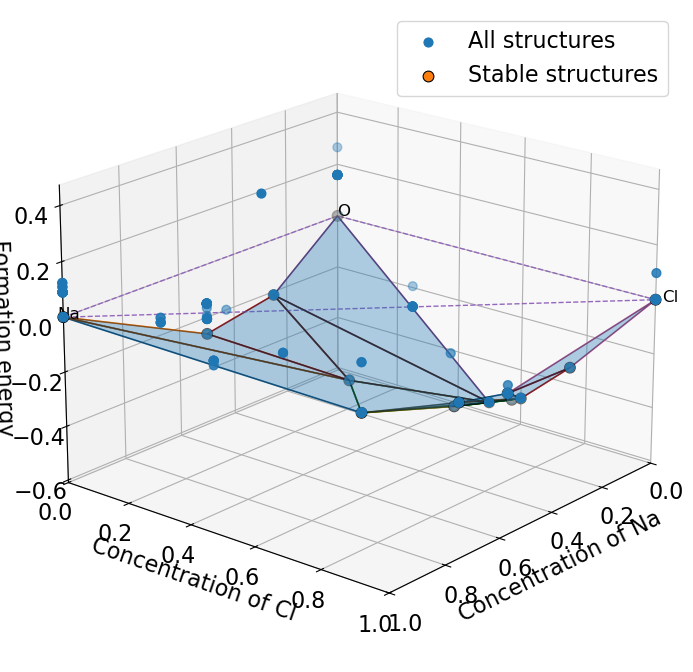

In [27]:
stable_vertices, lower_hull_faces = get_ternary_lower_hull(hull_pts)

plot_ternary_lower_hull_3d(
    hull_pts,
    lower_hull_faces,
    stable_vertices=stable_vertices,
    species_labels=("Na", "Cl", "O"),
)